In [1]:
import pandas as pd

from google.colab import files

uploaded = files.upload()

df = pd.read_csv('/content/Dataset1.csv')
display(df.head())

Saving Dataset1.csv to Dataset1.csv


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


# =====================
# LEVEL 1
# =====================


In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(186074, 12)

Column Names:
Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(

In [3]:
df[df["Train_No"] == 107].head(20)

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78


In [4]:
train_routes = df.groupby("Train_No").agg(
    Start_Station=("Station_Name", "first"),
    End_Station=("Station_Name", "last")
)

train_routes.head(20)

,Start_Station,End_Station
Train_No,,
107,SAWANTWADI R,MADGOAN JN.
108,MADGOAN JN.,SAWANTWADI R
128,MADGOAN JN.,CHHATRAPATI
290,DELHI-SAFDAR,DELHI-SAFDAR
401,AURANGABAD,VARANASI JN.
421,LUCKNOW JN.,SHRI MATA VA
422,SHRI MATA VA,LUCKNOW JN.
477,SIRSA,SIRSA
502,RAJENDRANAGA,AMBALA CANTT


In [5]:
train_routes["Total_Stops"] = df.groupby("Train_No").size()

train_routes.head(20)

,Start_Station,End_Station,Total_Stops
Train_No,,,
107,SAWANTWADI R,MADGOAN JN.,4
108,MADGOAN JN.,SAWANTWADI R,4
128,MADGOAN JN.,CHHATRAPATI,22
290,DELHI-SAFDAR,DELHI-SAFDAR,14
401,AURANGABAD,VARANASI JN.,12
421,LUCKNOW JN.,SHRI MATA VA,5
422,SHRI MATA VA,LUCKNOW JN.,5
477,SIRSA,SIRSA,14
502,RAJENDRANAGA,AMBALA CANTT,9


In [6]:
max_train = train_routes[train_routes["Total_Stops"] == train_routes["Total_Stops"].max()]

min_train = train_routes[train_routes["Total_Stops"] == train_routes["Total_Stops"].min()]

print("Train with Maximum Stops")
print(max_train)

print("\nTrain with Minimum Stops")
print(min_train)

Train with Maximum Stops
         Start_Station End_Station  Total_Stops
Train_No                                       
53041       HOWRAH JN.    JAYNAGAR          118

Train with Minimum Stops
         Start_Station   End_Station  Total_Stops
Train_No                                         
557             URKURA     PANJIPARA            2
3305       DHANBAD JN.       KUSUNDA            2
3306           KUSUNDA   DHANBAD JN.            2
5715      NEW JALPAIGU    KISHANGANJ            2
5716        KISHANGANJ  NEW JALPAIGU            2
...                ...           ...          ...
99499            THANE         VASHI            2
99500            VASHI         THANE            2
99501            THANE         VASHI            2
99502            VASHI         THANE            2
99503            THANE         VASHI            2

[1249 rows x 3 columns]


LEVEL 1 SUMMARY

• Dataset contains 186,074 records and 12 attributes.
• No missing values were found.
• Train 53041 has the maximum stops (118).
• Multiple local trains have only 2 stops.
• Dataset contains both short and long-distance routes.

# =====================
# LEVEL 2
# =====================



In [7]:
df[["Train_No", "Station_Name", "Arrival_time", "Departure_Time"]].head(20)

df[["Arrival_time", "Departure_Time"]].dtypes

,0
Arrival_time,object
Departure_Time,object


In [8]:
df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],
    format="%H:%M:%S",
    errors="coerce"
)

print(df[["Arrival_time", "Departure_Time"]].dtypes)

Arrival_time      datetime64[ns]
Departure_Time    datetime64[ns]
dtype: object


In [9]:
journey_times = df.groupby("Train_No").agg(
    Start_Time=("Departure_Time", "first"),
    End_Time=("Arrival_time", "last")
)

journey_times.head(20)

,Start_Time,End_Time
Train_No,,
107,1900-01-01 10:25:00,1900-01-01 12:10:00
108,1900-01-01 20:30:00,1900-01-01 22:25:00
128,1900-01-01 19:40:00,1900-01-01 17:45:00
290,1900-01-01 18:30:00,1900-01-01 02:30:00
401,1900-01-01 21:30:00,1900-01-01 10:00:00
421,1900-01-01 23:00:00,1900-01-01 08:00:00
422,1900-01-01 11:45:00,1900-01-01 14:30:00
477,1900-01-01 12:10:00,1900-01-01 15:20:00
502,1900-01-01 10:30:00,1900-01-01 09:30:00


In [10]:
journey_times_clean1 = journey_times.copy()

journey_times_clean1["Start_Time"] = journey_times_clean1["Start_Time"].dt.strftime("%H:%M:%S")
journey_times_clean1["End_Time"] = journey_times_clean1["End_Time"].dt.strftime("%H:%M:%S")

journey_times_clean1[["Start_Time","End_Time"]].head(20)

,Start_Time,End_Time
Train_No,,
107,10:25:00,12:10:00
108,20:30:00,22:25:00
128,19:40:00,17:45:00
290,18:30:00,02:30:00
401,21:30:00,10:00:00
421,23:00:00,08:00:00
422,11:45:00,14:30:00
477,12:10:00,15:20:00
502,10:30:00,09:30:00


In [11]:
journey_times["Start_Time"] = pd.to_datetime(journey_times["Start_Time"])
journey_times["End_Time"] = pd.to_datetime(journey_times["End_Time"])

journey_times["Journey_Duration"] = (
    journey_times["End_Time"] - journey_times["Start_Time"]
)

negative_mask = journey_times["Journey_Duration"] < pd.Timedelta(0)

journey_times.loc[
    negative_mask,
    "Journey_Duration"
] += pd.Timedelta(days=1)

journey_times["Duration_Hours"] = (
    journey_times["Journey_Duration"].dt.total_seconds() / 3600
)

print(journey_times.columns.tolist())

['Start_Time', 'End_Time', 'Journey_Duration', 'Duration_Hours']


In [12]:
journey_times_clean2 = journey_times.copy()

journey_times_clean2["Start_Time"] = journey_times_clean2["Start_Time"].dt.strftime("%H:%M:%S")
journey_times_clean2["End_Time"] = journey_times_clean2["End_Time"].dt.strftime("%H:%M:%S")

journey_times_clean2[
    ["Start_Time","End_Time","Journey_Duration"]
].head(20)

,Start_Time,End_Time,Journey_Duration
Train_No,,,
107,10:25:00,12:10:00,0 days 01:45:00
108,20:30:00,22:25:00,0 days 01:55:00
128,19:40:00,17:45:00,0 days 22:05:00
290,18:30:00,02:30:00,0 days 08:00:00
401,21:30:00,10:00:00,0 days 12:30:00
421,23:00:00,08:00:00,0 days 09:00:00
422,11:45:00,14:30:00,0 days 02:45:00
477,12:10:00,15:20:00,0 days 03:10:00
502,10:30:00,09:30:00,0 days 23:00:00


In [13]:
final_journey_table = journey_times.copy()

final_journey_table["Start_Time"] = final_journey_table["Start_Time"].dt.strftime("%H:%M:%S")
final_journey_table["End_Time"] = final_journey_table["End_Time"].dt.strftime("%H:%M:%S")

final_journey_table[
    ["Start_Time",
     "End_Time",
     "Journey_Duration",
     "Duration_Hours"]
].head(20)

,Start_Time,End_Time,Journey_Duration,Duration_Hours
Train_No,,,,
107,10:25:00,12:10:00,0 days 01:45:00,1.750000
108,20:30:00,22:25:00,0 days 01:55:00,1.916667
128,19:40:00,17:45:00,0 days 22:05:00,22.083333
290,18:30:00,02:30:00,0 days 08:00:00,8.000000
401,21:30:00,10:00:00,0 days 12:30:00,12.500000
421,23:00:00,08:00:00,0 days 09:00:00,9.000000
422,11:45:00,14:30:00,0 days 02:45:00,2.750000
477,12:10:00,15:20:00,0 days 03:10:00,3.166667
502,10:30:00,09:30:00,0 days 23:00:00,23.000000


In [14]:
journey_times["Route_Category"] = pd.cut(
    journey_times["Duration_Hours"],
    bins=[0, 6, 12, float('inf')],
    labels=["Short", "Medium", "Long"]
)

journey_times[
    ["Duration_Hours", "Route_Category"]
].head(20)

,Duration_Hours,Route_Category
Train_No,,
107,1.750000,Short
108,1.916667,Short
128,22.083333,Long
290,8.000000,Medium
401,12.500000,Long
421,9.000000,Medium
422,2.750000,Short
477,3.166667,Short
502,23.000000,Long


In [15]:
route_summary = journey_times["Route_Category"].value_counts()

print(route_summary)

Route_Category
Short     8324
Medium    1482
Long      1301
Name: count, dtype: int64


In [16]:
station_frequency = df.groupby("Station_Name")["Train_No"].nunique()

station_frequency.sort_values(ascending=False).head(20)

,Train_No
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


In [17]:
top_stations = (
    station_frequency
    .sort_values(ascending=False)
    .head(10)
)

print(top_stations)

Station_Name
CST-MUMBAI      1027
KALYAN JN        828
THANE            796
SEALDAH          745
CHENNAI BEAC     738
HOWRAH JN.       699
DADAR            598
DUM DUM JN.      463
KURLA            462
TAMBARAM         434
Name: Train_No, dtype: int64


In [18]:
print("\nLEVEL 2 SUMMARY")

print("- Arrival and departure times were standardized.")
print("- Total journey duration was calculated for every train.")
print("- Routes were categorized into Short, Medium, and Long.")
print("- Station-wise train frequency was generated.")
print("- CST-MUMBAI has the highest train frequency in the dataset.")
print("- Most routes belong to the Short category.")


LEVEL 2 SUMMARY
- Arrival and departure times were standardized.
- Total journey duration was calculated for every train.
- Routes were categorized into Short, Medium, and Long.
- Station-wise train frequency was generated.
- CST-MUMBAI has the highest train frequency in the dataset.
- Most routes belong to the Short category.


In [19]:
from google.colab import files

journey_times.to_csv("Level2_Output.csv")
files.download("Level2_Output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
print("Missing Values Check")
print(df[["Arrival_time", "Departure_Time"]].isnull().sum())

Missing Values Check
Arrival_time      0
Departure_Time    0
dtype: int64


In [21]:
print("Rows before removing duplicates:", len(df))

duplicates = df.duplicated().sum()
print("Duplicate rows found:", duplicates)

df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows before removing duplicates: 186074
Duplicate rows found: 0
Rows after removing duplicates: 186074


In [22]:
print("Station Sequence Check")

station_order_check = (
    df.groupby("Train_No")["Station_Name"]
    .apply(lambda x: x.is_monotonic_increasing)
)

print(station_order_check.value_counts())

Station Sequence Check
Station_Name
False    10417
True       696
Name: count, dtype: int64


In [23]:
print("Station Order Validation")

station_order_check = (
    df.groupby("Train_No")["SN"]
      .apply(lambda x: x.is_monotonic_increasing)
)

print(station_order_check.value_counts())

Station Order Validation
SN
True    11113
Name: count, dtype: int64


In [24]:
distance_check = (
    df.groupby("Train_No")["Distance"]
      .apply(lambda x: x.is_monotonic_increasing)
)

print(distance_check.value_counts())

Distance
True    11113
Name: count, dtype: int64


In [25]:
print("\nLEVEL 3 SUMMARY")

print("- Missing values check completed.")
print("- No missing values found in Arrival_time and Departure_Time.")
print("- Duplicate records check completed.")
print("- No duplicate records found.")
print("- Station order validated using SN column.")
print("- Distance progression validated using Distance column.")
print("- All 11113 train routes passed validation.")
print("- Verified dataset saved successfully.")


LEVEL 3 SUMMARY
- Missing values check completed.
- No missing values found in Arrival_time and Departure_Time.
- Duplicate records check completed.
- No duplicate records found.
- Station order validated using SN column.
- Distance progression validated using Distance column.
- All 11113 train routes passed validation.
- Verified dataset saved successfully.


In [26]:
from google.colab import files

df.to_csv("Level3_Verified_Dataset.csv", index=False)

files.download("Level3_Verified_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
avg_duration = (
    journey_times.groupby("Route_Category")["Duration_Hours"]
    .mean()
    .round(2)
)

print(avg_duration)

Route_Category
Short      1.95
Medium     8.62
Long      16.98
Name: Duration_Hours, dtype: float64


/tmp/ipykernel_1341/3789799476.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  journey_times.groupby("Route_Category")["Duration_Hours"]


In [28]:
high_traffic = (
    df.groupby("Station_Name")["Train_No"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

print(high_traffic)

Station_Name
CST-MUMBAI      1027
KALYAN JN        828
THANE            796
SEALDAH          745
CHENNAI BEAC     738
HOWRAH JN.       699
DADAR            598
DUM DUM JN.      463
KURLA            462
TAMBARAM         434
Name: Train_No, dtype: int64


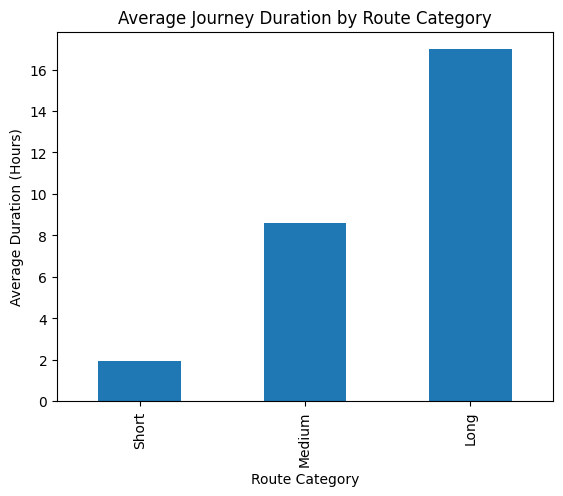

In [29]:
import matplotlib.pyplot as plt

avg_duration.plot(kind="bar")

plt.title("Average Journey Duration by Route Category")
plt.xlabel("Route Category")
plt.ylabel("Average Duration (Hours)")
plt.show()

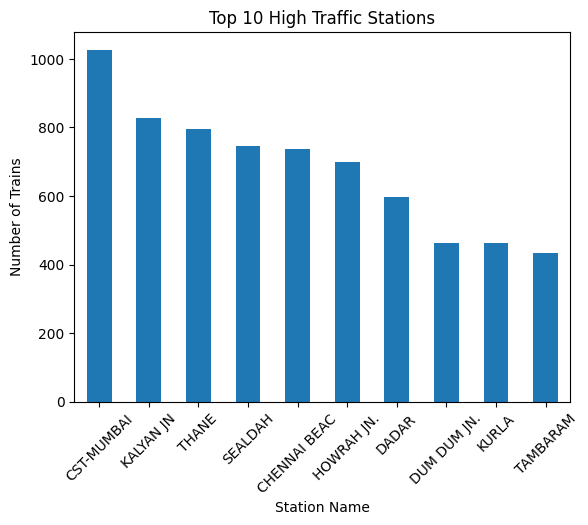

In [30]:
import matplotlib.pyplot as plt

high_traffic.plot(kind="bar")

plt.title("Top 10 High Traffic Stations")
plt.xlabel("Station Name")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45)

plt.show()

In [31]:
print("\nLEVEL 4 SUMMARY")

print("- Average journey duration by route category calculated.")
print("- Long routes have the highest average duration (16.98 hours).")
print("- Medium routes average 8.62 hours.")
print("- Short routes average 1.95 hours.")
print("- Top 10 high-traffic stations identified.")
print("- CST-MUMBAI is the busiest station with 1027 trains.")
print("- KALYAN JN and THANE are major railway hubs.")
print("- Visualizations created for route duration and station traffic.")


LEVEL 4 SUMMARY
- Average journey duration by route category calculated.
- Long routes have the highest average duration (16.98 hours).
- Medium routes average 8.62 hours.
- Short routes average 1.95 hours.
- Top 10 high-traffic stations identified.
- CST-MUMBAI is the busiest station with 1027 trains.
- KALYAN JN and THANE are major railway hubs.
- Visualizations created for route duration and station traffic.


In [32]:
from google.colab import files

df.to_csv("Level4_Analysis_Output.csv", index=False)

files.download("Level4_Analysis_Output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
station_pivot = pd.pivot_table(
    df,
    values="Train_No",
    index="Station_Name",
    aggfunc="nunique"
)

station_pivot = station_pivot.sort_values(
    by="Train_No",
    ascending=False
)

print(station_pivot.head(10))

              Train_No
Station_Name          
CST-MUMBAI        1027
KALYAN JN          828
THANE              796
SEALDAH            745
CHENNAI BEAC       738
HOWRAH JN.         699
DADAR              598
DUM DUM JN.        463
KURLA              462
TAMBARAM           434


In [34]:
route_station_crosstab = pd.crosstab(
    df["Route_Number"],
    df["Station_Name"]
)

print(route_station_crosstab.iloc[:10, :10])

Station_Name  .BAGHAJATIN  ABADA  ABHAIPUR  ABHANPUR JN.  ABHAYAPURI A  \
Route_Number                                                             
1                     217     90        62            12             6   

Station_Name  ABJUGANJ  ABOHAR  ABU ROAD  ABUTARA HALT  ACHAL GANJ  
Route_Number                                                        
1                    6      28       100             6           6  


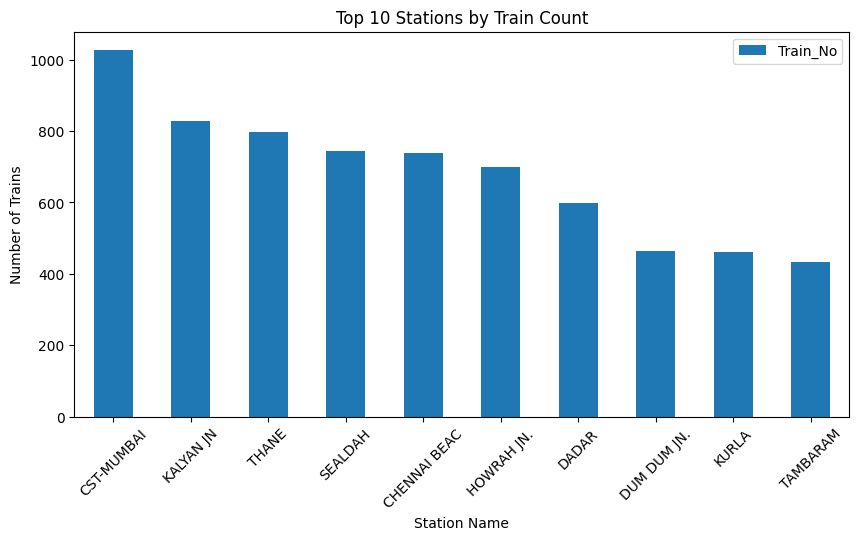

In [35]:
import matplotlib.pyplot as plt

station_pivot.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Stations by Train Count")
plt.ylabel("Number of Trains")
plt.xlabel("Station Name")
plt.xticks(rotation=45)
plt.show()

In [36]:
print("\nLEVEL 5 SUMMARY")

print("- Station-wise pivot table created successfully.")
print("- CST-MUMBAI is the busiest station with 1027 trains.")
print("- KALYAN JN and THANE are also major railway hubs.")
print("- Cross-tabulation between Route_Number and Station_Name completed.")
print("- Route_Number 1 contains all station records in the dataset.")
print("- Major metropolitan stations handle the highest train traffic.")
print("- Comparative visualization created for station-wise train distribution.")
print("- Advanced analysis completed successfully.")


LEVEL 5 SUMMARY
- Station-wise pivot table created successfully.
- CST-MUMBAI is the busiest station with 1027 trains.
- KALYAN JN and THANE are also major railway hubs.
- Cross-tabulation between Route_Number and Station_Name completed.
- Route_Number 1 contains all station records in the dataset.
- Major metropolitan stations handle the highest train traffic.
- Comparative visualization created for station-wise train distribution.
- Advanced analysis completed successfully.


In [38]:
from google.colab import files

df.to_csv("Level5_Analysis_Output.csv", index=False)

files.download("Level5_Analysis_Output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>